# Single Line Analysis - Notebook

In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [47]:
def preprocess(oct_img):
    retinal_fundus = oct_img[0:496, 0:496]
    H, W, _ = oct_img.shape
    w_r = W - 496
    gap_space = (w_r - 496) //2
    tomogram = oct_img[0:496, gap_space+496:gap_space+(2*496)] # width = 496
    retinal_fundus = cv2.resize(retinal_fundus, (256, 256)).astype(np.float32)
    tomogram = cv2.resize(tomogram, (256, 256)).astype(np.float32)
    input_features = [
        np.expand_dims(retinal_fundus, axis=0),
        np.expand_dims(tomogram, axis=0)
    ]
    return input_features

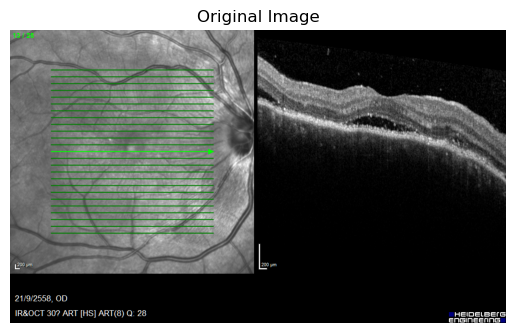

In [49]:
image = cv2.imread('../data/oct_image.png')
plt.title('Original Image')
plt.axis('off')
plt.imshow(image)

In [50]:
inputs_features = preprocess(image)

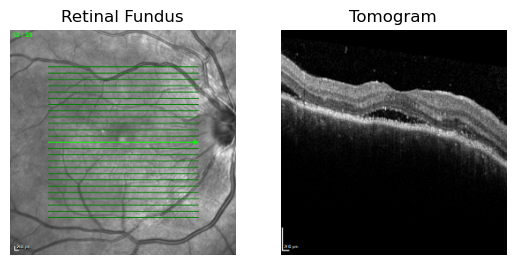

In [51]:
plt.subplot(1, 2, 1)
plt.title('Retinal Fundus')
plt.axis('off')
plt.imshow(inputs_features[0][0].astype(np.uint8))

plt.subplot(1, 2, 2)
plt.title('Tomogram')
plt.axis('off')
plt.imshow(inputs_features[1][0].astype(np.uint8))

In [52]:
cv2.imwrite('../data/retinal_fundus.png', inputs_features[0][0].astype(np.uint8))
cv2.imwrite('../data/tomogram.png', inputs_features[1][0].astype(np.uint8))

True